# Attribution Algorithm Code

## Setup

In [ ]:
!pip install -q ultralytics manga109api xgboost scikit-learn

from google.colab import drive
drive.mount('/drive')

import numpy as np
import os, xml.etree.ElementTree as ET, pickle, json
import manga109api
from ultralytics import YOLO
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

data_root      = "/drive/MyDrive/manga109_data/Manga109_released_2023_12_07"
dialog_ann_dir = "/drive/MyDrive/manga109_public_annotations/Manga109Dialog"
weights_path   = "/drive/MyDrive/CV-Comic-Project/baselines/manga109_yolov8/weights/best.pt"

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).


In [ ]:
api        = manga109api.Parser(root_dir=data_root)
all_books  = api.books
train_books = all_books[:int(len(all_books) * 0.8)]   # 87 books
val_books   = all_books[int(len(all_books) * 0.8):]   # 22 books
print(f"Train: {len(train_books)} books | Val: {len(val_books)} books")

Train: 87 books | Val: 22 books


## 1. Utilities

In [ ]:
def centroid(box):
    return np.array([(box[0]+box[2])/2, (box[1]+box[3])/2])

def edge_distance(a, b):
    dx = max(0, max(a[0],b[0]) - min(a[2],b[2]))
    dy = max(0, max(a[1],b[1]) - min(a[3],b[3]))
    return np.sqrt(dx**2 + dy**2)

def box_iou(a, b):
    ix1=max(a[0],b[0]); iy1=max(a[1],b[1])
    ix2=min(a[2],b[2]); iy2=min(a[3],b[3])
    inter = max(0,ix2-ix1)*max(0,iy2-iy1)
    union = (a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter
    return inter/(union+1e-8)

def same_frame(text_box, body_box, frames):
    def containing(box):
        cx,cy = centroid(box)
        for i,f in enumerate(frames):
            if f[0]<=cx<=f[2] and f[1]<=cy<=f[3]: return i
        return None
    t,b = containing(text_box), containing(body_box)
    return 1.0 if (t is not None and t==b) else 0.0

FEATURE_NAMES = [
    "edge_dist","centroid_dist","same_frame","iou",
    "above_bonus","rel_x","rel_y","text_area","body_area"
]

def extract_features(text_box, body_box, frames, img_w, img_h):
    diag = np.sqrt(img_w**2 + img_h**2)
    tc, bc = centroid(text_box), centroid(body_box)
    return [
        edge_distance(text_box, body_box) / diag,
        np.linalg.norm(tc - bc) / diag,
        same_frame(text_box, body_box, frames),
        box_iou(text_box, body_box),
        float(tc[1] < bc[1]),
        (tc[0]-bc[0]) / img_w,
        (tc[1]-bc[1]) / img_h,
        (text_box[2]-text_box[0])*(text_box[3]-text_box[1]) / (img_w*img_h),
        (body_box[2]-body_box[0])*(body_box[3]-body_box[1]) / (img_w*img_h),
    ]

print(f"Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")

Features (9): ['edge_dist', 'centroid_dist', 'same_frame', 'iou', 'above_bonus', 'rel_x', 'rel_y', 'text_area', 'body_area']


## 2. Manga109Dialog Loader

In [ ]:
def load_dialog_annotations(book, api, dialog_ann_dir):
    """
    load ground-truth (text_box and speaker_box) pairs from Manga109Dialog XML
    """
    xml_path = os.path.join(dialog_ann_dir, f"{book}.xml")
    if not os.path.exists(xml_path):
        return []

    base_ann = api.get_annotation(book=book)
    id_to_box = {}
    for page in base_ann['page']:
        for tag in ['body','text','face']:
            for item in page[tag]:
                id_to_box[item['@id']] = [
                    item['@xmin'],item['@ymin'],item['@xmax'],item['@ymax']
                ]

    tree = ET.parse(xml_path)
    pages_out = []
    for page_el in tree.getroot().find('pages').findall('page'):
        pairs = []
        for stt in page_el.findall('speaker_to_text'):
            tid, sid = stt.attrib['text_id'], stt.attrib['speaker_id']
            if tid in id_to_box and sid in id_to_box:
                pairs.append({'text_box': id_to_box[tid], 'speaker_box': id_to_box[sid]})
        if pairs:
            pages_out.append({
                'page_index': int(page_el.attrib['index']),
                'width':  int(page_el.attrib['width']),
                'height': int(page_el.attrib['height']),
                'pairs':  pairs,
            })
    return pages_out

# Test if properly loaded
pages = load_dialog_annotations("ARMS", api, dialog_ann_dir)
print(f"ARMS: {len(pages)} annotated pages | sample pair: {pages[0]['pairs'][0]}")

ARMS: 73 annotated pages | sample pair: {'text_box': [550, 660, 583, 696], 'speaker_box': [178, 660, 548, 965]}


## 3. YOLO Detection Helper

In [ ]:
model = YOLO(weights_path)

def get_detections(img_path, conf_thresh=0.25):
    """returns: (bodies, texts) in the form of [x1,y1,x2,y2,conf]"""
    res = model(img_path, verbose=False)[0]
    bodies, texts = [], []
    for box in res.boxes:
        cls  = int(box.cls.item())
        conf = float(box.conf.item())
        xyxy = box.xyxy[0].tolist()
        if cls == 0: bodies.append(xyxy + [conf])
        else:         texts.append(xyxy + [conf])
    return bodies, texts

def best_match_conf(gt_box, pred_boxes_with_conf, iou_thresh=0.3):
    """
    match a GT box to the highest-IoU YOLO prediction (if nothing matched, returns neutral of 0.5)
    """
    best_iou, best_conf = 0.0, 0.5   # default: neutral weight if unmatched
    for *xyxy, conf in pred_boxes_with_conf:
        iou = box_iou(gt_box, xyxy)
        if iou > best_iou:
            best_iou, best_conf = iou, conf
    return best_conf

print("YOLO loaded:", weights_path.split('/')[-3])

YOLO loaded: manga109_yolov8


## 4. Build Training Data

3 weight schemes to compare: uniform, page difficulty, and YOLO confidence


In [ ]:
def build_training_data(books, use_conf_weights=False, use_page_weights=False):
    """
    builds (X, y, w) over all Manga109Dialog-annotated pages in books
    """
    X_all, y_all, w_all = [], [], []
    skipped = 0

    for b_idx, book in enumerate(books):
        gt_pages   = load_dialog_annotations(book, api, dialog_ann_dir)
        if not gt_pages: continue

        base_ann    = api.get_annotation(book=book)
        page_lookup = {p['@index']: p for p in base_ann['page']}

        for page_data in gt_pages:
            page = page_lookup.get(page_data['page_index'])
            if page is None: continue

            img_w, img_h = page_data['width'], page_data['height']
            all_bodies = [[b['@xmin'],b['@ymin'],b['@xmax'],b['@ymax']]
                          for b in page['body']]
            all_frames = [[f['@xmin'],f['@ymin'],f['@xmax'],f['@ymax']]
                          for f in page['frame']]
            if not all_bodies: continue

            n_bodies = len(all_bodies)

            pred_bodies, pred_texts = [], []
            if use_conf_weights:
                img_path = os.path.join(data_root, "images", book,
                                        f"{page_data['page_index']:03d}.jpg")
                if not os.path.exists(img_path):
                    skipped += 1; continue
                pred_bodies, pred_texts = get_detections(img_path)

            for pair in page_data['pairs']:
                gt_text    = pair['text_box']
                gt_speaker = pair['speaker_box']

                # Confidence of the text bubble and its GT speaker detection
                if use_conf_weights:
                    text_conf = best_match_conf(gt_text,    pred_texts)
                    body_conf = best_match_conf(gt_speaker, pred_bodies)
                    pair_conf = np.sqrt(max(text_conf, 1e-6) * max(body_conf, 1e-6))
                    base_weight = 1.0 / pair_conf
                else:
                    base_weight = 1.0

                for body in all_bodies:
                    feats = extract_features(gt_text, body, all_frames, img_w, img_h)
                    label = 1 if box_iou(gt_speaker, body) >= 0.5 else 0

                    if use_page_weights:
                        w = float(n_bodies)
                    else:
                        w = base_weight

                    X_all.append(feats); y_all.append(label); w_all.append(w)

        if (b_idx+1) % 15 == 0:
            print(f"  {b_idx+1}/{len(books)} books | {len(X_all):,} samples")

    X = np.array(X_all, dtype=np.float32)
    y = np.array(y_all, dtype=np.int32)
    w = np.array(w_all, dtype=np.float32)
    w = w / w.mean() #normalize

    pos = y.sum(); neg = len(y)-pos
    print(f"Done: {len(X):,} samples | pos: {pos:,} ({pos/len(y)*100:.1f}%) | "
          f"neg: {neg:,} | skipped pages: {skipped}")
    print(f"Weight range: {w.min():.3f} – {w.max():.3f} | mean: {w.mean():.3f}")
    return X, y, w

## 5. Collect Training Data (all 3 schemes)

In [ ]:
CACHE_DIR  = "/drive/MyDrive/CV-Comic-Project/training_data_cache"
CACHE_PATH = os.path.join(CACHE_DIR, "Xy_weights.npz")

if os.path.exists(CACHE_PATH):
    data      = np.load(CACHE_PATH)
    X_train   = data["X_train"]
    y_train   = data["y_train"]
    w_uniform = data["w_uniform"]
    w_page    = data["w_page"]
    w_conf    = data["w_conf"]
    print(f"✓ Loaded from cache: {X_train.shape[0]:,} samples")
    print(f"  w_uniform range: {w_uniform.min():.3f}–{w_uniform.max():.3f}")
    print(f"  w_page range:    {w_page.min():.3f}–{w_page.max():.3f}")
    print(f"  w_conf range:    {w_conf.min():.3f}–{w_conf.max():.3f}")
else:
    print("No cache found — running build_training_data()")
    print("=== Uniform weights (baseline) ===")
    X_train, y_train, w_uniform = build_training_data(train_books)
    print()

    print("=== Page-difficulty weights ===")
    _, _, w_page = build_training_data(train_books, use_page_weights=True)
    print()

    print("=== YOLO-confidence weights (paper method) ===")
    _, _, w_conf = build_training_data(train_books, use_conf_weights=True)

✓ Loaded from cache: 1,998,955 samples
  w_uniform range: 1.000–1.000
  w_page range:    0.043–3.120
  w_conf range:    0.776–2.936


In [ ]:
CACHE_DIR = "/drive/MyDrive/CV-Comic-Project/training_data_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
CACHE_PATH = os.path.join(CACHE_DIR, "Xy_weights.npz")

np.savez_compressed(
    CACHE_PATH,
    X_train   = X_train,
    y_train   = y_train,
    w_uniform = w_uniform,
    w_page    = w_page,
    w_conf    = w_conf,
)
print(f"Saved → {CACHE_PATH}  ({os.path.getsize(CACHE_PATH)/1e6:.1f} MB)")

Saved → /drive/MyDrive/CV-Comic-Project/training_data_cache/Xy_weights.npz  (37.5 MB)


## 6. Train/Val Split

In [ ]:
SPLIT_PATH  = os.path.join(CACHE_DIR, "split_scaled.npz")
SCALER_PATH = os.path.join(CACHE_DIR, "scaler.pkl")

if os.path.exists(SPLIT_PATH) and os.path.exists(SCALER_PATH):
    d = np.load(SPLIT_PATH)
    X_tr, X_xval         = d["X_tr"],         d["X_xval"]
    y_tr, y_xval         = d["y_tr"],          d["y_xval"]
    idx_tr, idx_xval     = d["idx_tr"],        d["idx_xval"]
    X_tr_sc, X_xv_sc     = d["X_tr_sc"],       d["X_xv_sc"]
    w_uniform_tr         = d["w_uniform_tr"];  w_uniform_xval = d["w_uniform_xval"]
    w_page_tr            = d["w_page_tr"];     w_page_xval    = d["w_page_xval"]
    w_conf_tr            = d["w_conf_tr"];     w_conf_xval    = d["w_conf_xval"]

    with open(SCALER_PATH, "rb") as f:
        scaler = pickle.load(f)

    neg_n = (y_tr==0).sum(); pos_n = (y_tr==1).sum()
    scale_pos = neg_n / pos_n
    print(f"✓ Loaded split: train={len(X_tr):,} | val={len(X_xval):,}")
    print(f"  scale_pos_weight: {scale_pos:.2f}")
else:
    print("No split cache — running train_test_split()")

    # Split is 80% train, 20% internal XGB val
    # This is split WITHIN the 87 training volumes (validation books are not touched)
    X_tr, X_xval, y_tr, y_xval, idx_tr, idx_xval = train_test_split(
        X_train, y_train, np.arange(len(y_train)),
        test_size=0.2, random_state=42, stratify=y_train
    )
    w_uniform_tr = w_uniform[idx_tr]; w_uniform_xval = w_uniform[idx_xval]
    w_page_tr    = w_page[idx_tr];    w_page_xval    = w_page[idx_xval]
    w_conf_tr    = w_conf[idx_tr];    w_conf_xval    = w_conf[idx_xval]

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_xv_sc = scaler.transform(X_xval)

    neg_n = (y_tr==0).sum(); pos_n = (y_tr==1).sum()
    scale_pos = neg_n / pos_n
    print(f"XGB train: {len(X_tr):,} | XGB val: {len(X_xval):,}")
    print(f"scale_pos_weight: {scale_pos:.2f}  (critical — fixes majority-class collapse)")

    # sanity check that hard pages should have higher weight under conf scheme
    low_conf_mask  = w_conf_tr > w_conf_tr.mean()
    high_conf_mask = w_conf_tr <= w_conf_tr.mean()
    print(f"\nConf weight check:")
    print(f"  Hard pairs (low conf) avg weight:  {w_conf_tr[low_conf_mask].mean():.3f}")
    print(f"  Easy pairs (high conf) avg weight: {w_conf_tr[high_conf_mask].mean():.3f}")

✓ Loaded split: train=1,599,164 | val=399,791
  scale_pos_weight: 17.45


In [ ]:
SPLIT_PATH  = os.path.join(CACHE_DIR, "split_scaled.npz")
SCALER_PATH = os.path.join(CACHE_DIR, "scaler.pkl")

np.savez_compressed(
    SPLIT_PATH,
    X_tr        = X_tr,        X_xval      = X_xval,
    y_tr        = y_tr,        y_xval      = y_xval,
    idx_tr      = idx_tr,      idx_xval    = idx_xval,
    X_tr_sc     = X_tr_sc,     X_xv_sc     = X_xv_sc,
    w_uniform_tr= w_uniform_tr, w_uniform_xval= w_uniform_xval,
    w_page_tr   = w_page_tr,   w_page_xval = w_page_xval,
    w_conf_tr   = w_conf_tr,   w_conf_xval = w_conf_xval,
)
with open(SCALER_PATH, "wb") as f:
    pickle.dump(scaler, f)

print(f"Saved split  → {SPLIT_PATH}  ({os.path.getsize(SPLIT_PATH)/1e6:.1f} MB)")
print(f"Saved scaler → {SCALER_PATH}")

Saved split  → /drive/MyDrive/CV-Comic-Project/training_data_cache/split_scaled.npz  (107.4 MB)
Saved scaler → /drive/MyDrive/CV-Comic-Project/training_data_cache/scaler.pkl


## 7. Train XGBoost (all 3 schemes)

In [ ]:
XGB_PARAMS = dict(
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    device="cuda",
    tree_method="hist",
    eval_metric="auc",
    early_stopping_rounds=20,
    n_estimators=400,
    random_state=42,
)

trained = {}

for name, w_tr, w_xval in [
    ("uniform",   w_uniform_tr, w_uniform_xval),
    ("page_diff", w_page_tr,    w_page_xval),
    ("conf",      w_conf_tr,    w_conf_xval),
]:
    print(f"\n── Training: {name} ──")
    clf = XGBClassifier(**XGB_PARAMS)
    clf.fit(
        X_tr_sc, y_tr,
        sample_weight=w_tr,
        eval_set=[(X_xv_sc, y_xval)],
        sample_weight_eval_set=[w_xval],
        verbose=50,
    )
    val_probs = clf.predict_proba(X_xv_sc)[:, 1]
    val_auc   = roc_auc_score(y_xval, val_probs)
    print(f"Best iter: {clf.best_iteration} | Val AUC: {val_auc:.5f}")
    trained[name] = {"clf": clf, "val_auc": val_auc}

print("\nAll models trained.")


── Training: uniform ──
[0]	validation_0-auc:0.95750
[50]	validation_0-auc:0.96243
[100]	validation_0-auc:0.96339
[150]	validation_0-auc:0.96388
[200]	validation_0-auc:0.96418
[250]	validation_0-auc:0.96433
[300]	validation_0-auc:0.96441
[350]	validation_0-auc:0.96445
[399]	validation_0-auc:0.96449


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [05:00:45] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best iter: 397 | Val AUC: 0.96449

── Training: page_diff ──
[0]	validation_0-auc:0.96507
[50]	validation_0-auc:0.97002
[100]	validation_0-auc:0.97089
[150]	validation_0-auc:0.97138
[200]	validation_0-auc:0.97166
[250]	validation_0-auc:0.97174
[300]	validation_0-auc:0.97182
[350]	validation_0-auc:0.97184
[399]	validation_0-auc:0.97186
Best iter: 397 | Val AUC: 0.96446

── Training: conf ──
[0]	validation_0-auc:0.95664
[50]	validation_0-auc:0.96135
[100]	validation_0-auc:0.96228
[150]	validation_0-auc:0.96277
[200]	validation_0-auc:0.96308
[250]	validation_0-auc:0.96322
[300]	validation_0-auc:0.96332
[350]	validation_0-auc:0.96335
[379]	validation_0-auc:0.96336
Best iter: 359 | Val AUC: 0.96447

All models trained.


## 8. Feature Importance Comparison

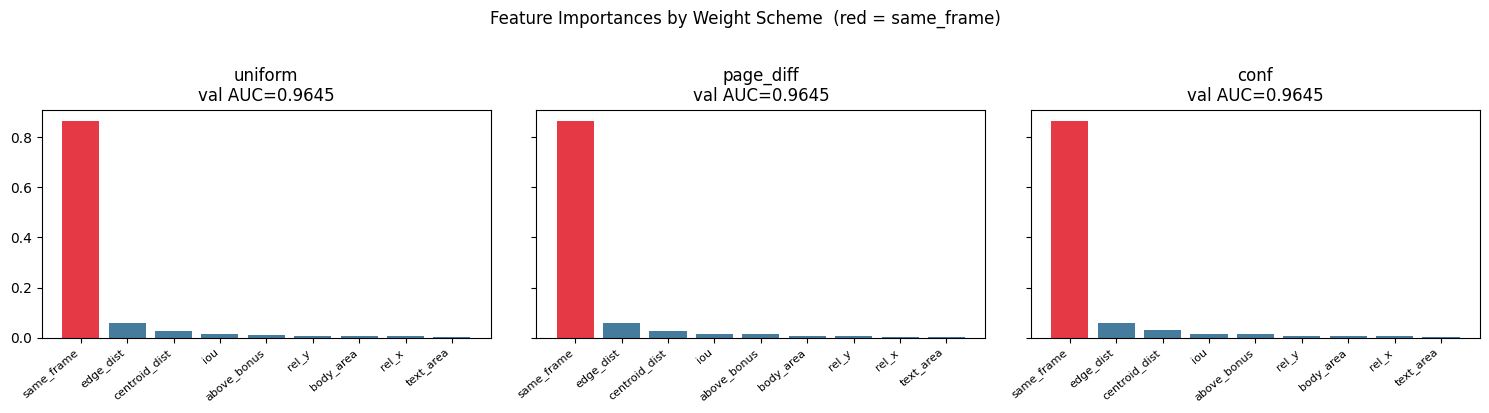

Saved feature_importance_compare.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, d) in zip(axes, trained.items()):
    imp = d['clf'].feature_importances_
    idx = np.argsort(imp)[::-1]
    colors = ["#e63946" if FEATURE_NAMES[i]=="same_frame" else "#457b9d" for i in idx]
    ax.bar(range(len(FEATURE_NAMES)), imp[idx], color=colors)
    ax.set_xticks(range(len(FEATURE_NAMES)))
    ax.set_xticklabels([FEATURE_NAMES[i] for i in idx], rotation=40, ha="right", fontsize=8)
    ax.set_title(f"{name}\nval AUC={d['val_auc']:.4f}")
fig.suptitle("Feature Importances by Weight Scheme  (red = same_frame)", y=1.02)
plt.tight_layout()
plt.savefig("/content/feature_importance_compare.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved feature_importance_compare.png")

## 9. Attribution Functions

In [ ]:
def attribute_nearest_edge(bodies, texts, frames, img_w, img_h):
    out = []
    for t in texts:
        if not bodies: out.append((t, None, 0.0)); continue
        dists = [edge_distance(t, b) for b in bodies]
        i = np.argmin(dists)
        out.append((t, bodies[i], 1/(dists[i]+1e-8)))
    return out

def attribute_nearest_centroid(bodies, texts, frames, img_w, img_h):
    out = []
    for t in texts:
        if not bodies: out.append((t, None, 0.0)); continue
        dists = [np.linalg.norm(centroid(t)-centroid(b)) for b in bodies]
        i = np.argmin(dists)
        out.append((t, bodies[i], 1/(dists[i]+1e-8)))
    return out

def make_learned_fn(clf, scaler):
    def attribute_learned(bodies, texts, frames, img_w, img_h):
        out = []
        for t in texts:
            if not bodies: out.append((t, None, 0.0)); continue
            feats = [extract_features(t, b, frames, img_w, img_h) for b in bodies]
            probs = clf.predict_proba(scaler.transform(feats))[:, 1]
            i     = np.argmax(probs)
            out.append((t, bodies[i], probs[i]))
        return out
    return attribute_learned

## 10. Evaluation Function

In [ ]:
def evaluate(attribution_fn, books, iou_threshold=0.5, cache=None):
    """
    evaluates attribution against Manga109Dialog GT
    """
    total = missed = unattributed = wrong = correct = 0

    for book in books:
        gt_pages    = load_dialog_annotations(book, api, dialog_ann_dir)
        base_ann    = api.get_annotation(book=book)
        page_lookup = {p['@index']: p for p in base_ann['page']}

        for page_data in gt_pages:
            page_idx = page_data['page_index']

            if cache is not None:
                entry = cache.get((book, page_idx))
                if entry is None: continue
                pred_bodies, pred_texts = entry
            else:
                img_path = os.path.join(data_root, "images", book, f"{page_idx:03d}.jpg")
                if not os.path.exists(img_path): continue
                pred_b_raw, pred_t_raw = get_detections(img_path)
                pred_bodies = [r[:4] for r in pred_b_raw]
                pred_texts  = [r[:4] for r in pred_t_raw]

            page   = page_lookup.get(page_idx, {})
            frames = [[f['@xmin'],f['@ymin'],f['@xmax'],f['@ymax']]
                      for f in page.get('frame', [])]
            img_w, img_h = page_data['width'], page_data['height']

            attributions = attribution_fn(pred_bodies, pred_texts, frames, img_w, img_h)
            t2s = {tuple(t): s for t, s, _ in attributions}

            for pair in page_data['pairs']:
                gt_text, gt_speaker = pair['text_box'], pair['speaker_box']
                total += 1

                matched = next(
                    (tuple(pt) for pt in pred_texts if box_iou(gt_text, pt) >= iou_threshold),
                    None
                )
                if matched is None: missed += 1; continue

                pred_s = t2s.get(matched)
                if pred_s is None: unattributed += 1; continue

                if box_iou(gt_speaker, pred_s) >= iou_threshold: correct += 1
                else: wrong += 1

    acc      = correct / (total + 1e-8)
    cond_acc = correct / (total - missed + 1e-8)
    print(f"  Total: {total:,} | Missed: {missed} ({missed/total*100:.1f}%) | "
          f"Wrong: {wrong} ({wrong/total*100:.1f}%) | Correct: {correct} ({correct/total*100:.1f}%)")
    print(f"  Acc: {acc:.4f} | Cond Acc: {cond_acc:.4f}")
    return {"total":total,"correct":correct,"missed":missed,"wrong":wrong,
            "accuracy":round(acc,4),"conditional_accuracy":round(cond_acc,4)}

In [ ]:
print("Caching YOLO detections for val books...")
detection_cache = {}  # (book, page_idx) --> (pred_bodies, pred_texts)

for book in val_books:
    gt_pages = load_dialog_annotations(book, api, dialog_ann_dir)
    for page_data in gt_pages:
        page_idx = page_data['page_index']
        img_path = os.path.join(data_root, "images", book, f"{page_idx:03d}.jpg")
        if not os.path.exists(img_path):
            continue
        pred_b_raw, pred_t_raw = get_detections(img_path)
        detection_cache[(book, page_idx)] = (
            [r[:4] for r in pred_b_raw],   #bodies without conf
            [r[:4] for r in pred_t_raw],   #texts without conf
        )

print(f"Cached {len(detection_cache)} pages across {len(val_books)} val books.")

Caching YOLO detections for val books...
Cached 1941 pages across 22 val books.


## 11. Final Comparison on Val Books

In [ ]:
variants = {
    "nearest_centroid":  attribute_nearest_centroid,
    "nearest_edge":      attribute_nearest_edge,
    "xgb_uniform":       make_learned_fn(trained["uniform"]["clf"],   scaler),
    "xgb_page_diff":     make_learned_fn(trained["page_diff"]["clf"], scaler),
    "xgb_conf_weighted": make_learned_fn(trained["conf"]["clf"],      scaler),
}

results = {}
for name, fn in variants.items():
    print(f"\n── {name} ──")
    results[name] = evaluate(fn, val_books, cache=detection_cache)

print(f"\n{'Method':<22} {'Acc':>7} {'Cond Acc':>10} {'Wrong%':>8} {'Δ vs uniform':>13}")
print("─" * 65)
base_acc = results["xgb_uniform"]["accuracy"]
for name, r in results.items():
    wrong_pct = r['wrong'] / r['total'] * 100
    delta = r['accuracy'] - base_acc
    delta_str = f"{delta:+.4f}" if name != "xgb_uniform" else "  baseline"
    print(f"{name:<22} {r['accuracy']:>7.4f} {r['conditional_accuracy']:>10.4f} "
          f"{wrong_pct:>7.1f}% {delta_str:>13}")


── nearest_centroid ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 9586 (37.6%) | Correct: 14158 (55.6%)
  Acc: 0.5558 | Cond Acc: 0.5963

── nearest_edge ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 9081 (35.6%) | Correct: 14663 (57.6%)
  Acc: 0.5756 | Cond Acc: 0.6175

── xgb_uniform ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 8486 (33.3%) | Correct: 15258 (59.9%)
  Acc: 0.5989 | Cond Acc: 0.6426

── xgb_page_diff ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 8559 (33.6%) | Correct: 15185 (59.6%)
  Acc: 0.5961 | Cond Acc: 0.6395

── xgb_conf_weighted ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 8387 (32.9%) | Correct: 15357 (60.3%)
  Acc: 0.6028 | Cond Acc: 0.6468

Method                     Acc   Cond Acc   Wrong%  Δ vs uniform
─────────────────────────────────────────────────────────────────
nearest_centroid        0.5558     0.5963    37.6%       -0.0431
nearest_edge            0.5756     0.6175    35.6%       -0.0233
xgb_uniform             0.5989     0.64

## 12. Save Models & Results

In [ ]:
save_dir = "/drive/MyDrive/CV-Comic-Project/baselines/"
os.makedirs(save_dir, exist_ok=True)

for name, d in trained.items():
    path = os.path.join(save_dir, f"xgb_{name}.pkl")
    with open(path, "wb") as f:
        pickle.dump({"clf": d["clf"], "scaler": scaler}, f)
    print(f"Saved xgb_{name}.pkl")

with open(os.path.join(save_dir, "attribution_results.json"), "w") as f:
    json.dump(results, f, indent=2)

print("\nFinal results:")
print(json.dumps({k: {"acc": v["accuracy"], "cond_acc": v["conditional_accuracy"]}
                  for k, v in results.items()}, indent=2))

Saved xgb_uniform.pkl
Saved xgb_page_diff.pkl
Saved xgb_conf.pkl

Final results:
{
  "nearest_centroid": {
    "acc": 0.5558,
    "cond_acc": 0.5963
  },
  "nearest_edge": {
    "acc": 0.5756,
    "cond_acc": 0.6175
  },
  "xgb_uniform": {
    "acc": 0.5989,
    "cond_acc": 0.6426
  },
  "xgb_page_diff": {
    "acc": 0.5961,
    "cond_acc": 0.6395
  },
  "xgb_conf_weighted": {
    "acc": 0.6028,
    "cond_acc": 0.6468
  }
}


## 13. Ablation on Feature Set ( h_overlap back + same_frame )

In [ ]:
# v3 features = all 10 features used
FEATURE_NAMES_V3 = [
    "edge_dist","centroid_dist","same_frame","iou",
    "above_bonus","rel_x","rel_y","text_area","body_area",
    "h_overlap",
]

def h_overlap_score(a, b):
    """Horizontal band overlap fraction between two boxes."""
    overlap = max(0, min(a[3],b[3]) - max(a[1],b[1]))
    union   = max(a[3],b[3]) - min(a[1],b[1])
    return overlap / (union + 1e-8)

def extract_features_v3(text_box, body_box, frames, img_w, img_h):
    diag = np.sqrt(img_w**2 + img_h**2)
    tc, bc = centroid(text_box), centroid(body_box)
    return [
        edge_distance(text_box, body_box) / diag,
        np.linalg.norm(tc - bc) / diag,
        same_frame(text_box, body_box, frames),
        box_iou(text_box, body_box),
        float(tc[1] < bc[1]),
        (tc[0]-bc[0]) / img_w,
        (tc[1]-bc[1]) / img_h,
        (text_box[2]-text_box[0])*(text_box[3]-text_box[1]) / (img_w*img_h),
        (body_box[2]-body_box[0])*(body_box[3]-body_box[1]) / (img_w*img_h),
        h_overlap_score(text_box, body_box),
    ]

print(f"V3 features ({len(FEATURE_NAMES_V3)}): {FEATURE_NAMES_V3}")

V3 features (10): ['edge_dist', 'centroid_dist', 'same_frame', 'iou', 'above_bonus', 'rel_x', 'rel_y', 'text_area', 'body_area', 'h_overlap']


In [ ]:
def build_training_data_v3(books):
    X_all, y_all = [], []
    for book in books:
        gt_pages   = load_dialog_annotations(book, api, dialog_ann_dir)
        if not gt_pages: continue
        base_ann    = api.get_annotation(book=book)
        page_lookup = {p['@index']: p for p in base_ann['page']}

        for page_data in gt_pages:
            page = page_lookup.get(page_data['page_index'])
            if page is None: continue
            img_w, img_h = page_data['width'], page_data['height']
            all_bodies = [[b['@xmin'],b['@ymin'],b['@xmax'],b['@ymax']] for b in page['body']]
            all_frames = [[f['@xmin'],f['@ymin'],f['@xmax'],f['@ymax']] for f in page['frame']]
            if not all_bodies: continue

            for pair in page_data['pairs']:
                gt_text, gt_speaker = pair['text_box'], pair['speaker_box']
                for body in all_bodies:
                    feats = extract_features_v3(gt_text, body, all_frames, img_w, img_h)
                    label = 1 if box_iou(gt_speaker, body) >= 0.5 else 0
                    X_all.append(feats); y_all.append(label)

    X = np.array(X_all, dtype=np.float32)
    y = np.array(y_all, dtype=np.int32)
    print(f"V3 data: {len(X):,} samples | pos: {y.sum():,} ({y.mean()*100:.1f}%)")
    return X, y

X_train_v3, y_train_v3 = build_training_data_v3(train_books)

V3 data: 1,998,955 samples | pos: 108,348 (5.4%)


In [ ]:
X_tr_v3, X_xval_v3, y_tr_v3, y_xval_v3, idx_tr_v3, idx_xval_v3 = train_test_split(
    X_train_v3, y_train_v3, np.arange(len(y_train_v3)),
    test_size=0.2, random_state=42, stratify=y_train_v3
)

scaler_v3  = StandardScaler()
X_tr_v3_sc = scaler_v3.fit_transform(X_tr_v3)
X_xv_v3_sc = scaler_v3.transform(X_xval_v3)


w_conf_tr_v3   = w_conf[idx_tr_v3]
w_conf_xval_v3 = w_conf[idx_xval_v3]

neg_n = (y_tr_v3==0).sum(); pos_n = (y_tr_v3==1).sum()
scale_pos_v3 = neg_n / pos_n
print(f"scale_pos_weight: {scale_pos_v3:.2f}")

scale_pos_weight: 17.45


In [ ]:
# train 2 variants (early stopping vs fixed 300 trees)
trained_v3 = {}

for name, n_est, early_stop, w_tr, w_xval in [
    # With early stopping + conf weights (apple-to-apple vs §7 best)
    ("v3_conf_early",  400, 20,   w_conf_tr_v3, w_conf_xval_v3),
    # Fixed 300 trees + conf weights (matches old run's tree count)
    ("v3_conf_fixed300", 300, None, w_conf_tr_v3, w_conf_xval_v3),
    # Fixed 300 + uniform (isolates whether weighting or tree count drove old 63%)
    ("v3_uniform_fixed300", 300, None, np.ones(len(y_tr_v3)), np.ones(len(y_xval_v3))),
]:
    print(f"\n── {name} ──")
    clf = XGBClassifier(
        n_estimators=n_est,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_v3,
        subsample=0.8,
        colsample_bytree=0.8,
        device="cuda",
        tree_method="hist",
        eval_metric="auc",
        early_stopping_rounds=early_stop,
        random_state=42,
    )
    clf.fit(
        X_tr_v3_sc, y_tr_v3,
        sample_weight=w_tr,
        eval_set=[(X_xv_v3_sc, y_xval_v3)],
        sample_weight_eval_set=[w_xval],
        verbose=100,
    )
    val_probs = clf.predict_proba(X_xv_v3_sc)[:, 1]
    val_auc   = roc_auc_score(y_xval_v3, val_probs)
    best_iter = getattr(clf, 'best_iteration', n_est)
    print(f"Best iter: {best_iter} | Val AUC: {val_auc:.5f}")
    trained_v3[name] = {"clf": clf, "val_auc": val_auc}


── v3_conf_early ──
[0]	validation_0-auc:0.95675
[100]	validation_0-auc:0.96254
[200]	validation_0-auc:0.96327
[300]	validation_0-auc:0.96351
[399]	validation_0-auc:0.96361
Best iter: 393 | Val AUC: 0.96471

── v3_conf_fixed300 ──
[0]	validation_0-auc:0.95675
[100]	validation_0-auc:0.96254
[200]	validation_0-auc:0.96327
[299]	validation_0-auc:0.96351
Best iter: 300 | Val AUC: 0.96461

── v3_uniform_fixed300 ──
[0]	validation_0-auc:0.95756
[100]	validation_0-auc:0.96359
[200]	validation_0-auc:0.96438
[299]	validation_0-auc:0.96461
Best iter: 300 | Val AUC: 0.96461


In [ ]:
# Now evaluate on valdidation books
def make_learned_fn_v3(clf, scaler):
    def attribute(bodies, texts, frames, img_w, img_h):
        out = []
        for t in texts:
            if not bodies: out.append((t, None, 0.0)); continue
            feats = [extract_features_v3(t, b, frames, img_w, img_h) for b in bodies]
            probs = clf.predict_proba(scaler.transform(feats))[:, 1]
            i = np.argmax(probs)
            out.append((t, bodies[i], probs[i]))
        return out
    return attribute

variants_v3 = {k: make_learned_fn_v3(d["clf"], scaler_v3) for k, d in trained_v3.items()}

results_v3 = {}
for name, fn in variants_v3.items():
    print(f"\n── {name} ──")
    results_v3[name] = evaluate(fn, val_books)


── v3_conf_early ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 8366 (32.8%) | Correct: 15378 (60.4%)
  Acc: 0.6037 | Cond Acc: 0.6477

── v3_conf_fixed300 ──


In [ ]:
# full comparison table including prior runs
all_results = {**results, **results_v3}

print(f"\n{'Method':<26} {'Acc':>7} {'Cond Acc':>10} {'Wrong%':>8} {'Δ vs xgb_uniform':>18}")
print("─" * 75)
base = all_results["xgb_uniform"]["accuracy"]
for name, r in all_results.items():
    wrong_pct  = r['wrong'] / r['total'] * 100
    delta      = r['accuracy'] - base
    delta_str  = f"{delta:+.4f}" if name != "xgb_uniform" else "  baseline"
    print(f"{name:<26} {r['accuracy']:>7.4f} {r['conditional_accuracy']:>10.4f} "
          f"{wrong_pct:>7.1f}% {delta_str:>18}")

In [ ]:
# feature importance for best v3 model
best_v3_name = max(trained_v3, key=lambda k: trained_v3[k]["val_auc"])
best_v3_clf  = trained_v3[best_v3_name]["clf"]

imp = best_v3_clf.feature_importances_
idx = np.argsort(imp)[::-1]

plt.figure(figsize=(10, 4))
colors = ["#e63946" if FEATURE_NAMES_V3[i] in ("same_frame","h_overlap") else "#457b9d"
          for i in idx]
plt.bar(range(len(FEATURE_NAMES_V3)), imp[idx], color=colors)
plt.xticks(range(len(FEATURE_NAMES_V3)),
           [FEATURE_NAMES_V3[i] for i in idx], rotation=40, ha="right")
plt.title(f"Feature Importance — {best_v3_name}  (red = ablation features)")
plt.tight_layout()
plt.savefig("/content/feature_importance_v3.png", dpi=150, bbox_inches="tight")
plt.show()

for name, d in trained_v3.items():
    path = f"/drive/MyDrive/CV-Comic-Project/baselines/xgb_{name}.pkl"
    with open(path, "wb") as f:
        pickle.dump({"clf": d["clf"], "scaler": scaler_v3}, f)
    print(f"Saved {name}")

## 14. YOLO-matched Training Coordinates


In [ ]:
def build_training_data_yolo_matched(books, use_conf_weights=True, iou_thresh=0.3):
    """
    similar to build_training_data, but computes features from YOLO-detected box coordinates instead of GT coordinates
    """
    X_all, y_all, w_all = [], [], []
    dropped_pairs = 0

    for b_idx, book in enumerate(books):
        gt_pages = load_dialog_annotations(book, api, dialog_ann_dir)
        if not gt_pages: continue

        base_ann    = api.get_annotation(book=book)
        page_lookup = {p['@index']: p for p in base_ann['page']}

        for page_data in gt_pages:
            page = page_lookup.get(page_data['page_index'])
            if page is None: continue

            img_w, img_h = page_data['width'], page_data['height']
            all_frames   = [[f['@xmin'],f['@ymin'],f['@xmax'],f['@ymax']]
                            for f in page['frame']]

            img_path = os.path.join(
                data_root, "images", book,
                f"{page_data['page_index']:03d}.jpg"
            )
            if not os.path.exists(img_path): continue

            # YOLO detections
            det_bodies_raw, det_texts_raw = get_detections(img_path)
            det_bodies = [d[:4] for d in det_bodies_raw]  # strip conf
            det_texts  = [d[:4] for d in det_texts_raw]

            if not det_bodies or not det_texts: continue

            for pair in page_data['pairs']:
                gt_text    = pair['text_box']
                gt_speaker = pair['speaker_box']

                # Match GT text bubble to best detected text box
                best_text_iou, matched_text = 0.0, None
                for dt in det_texts:
                    v = box_iou(gt_text, dt)
                    if v > best_text_iou:
                        best_text_iou, matched_text = v, dt
                if best_text_iou < iou_thresh:
                    dropped_pairs += 1
                    continue

                # Match GT speaker to best detected body box
                best_body_iou, matched_speaker = 0.0, None
                for db in det_bodies:
                    v = box_iou(gt_speaker, db)
                    if v > best_body_iou:
                        best_body_iou, matched_speaker = v, db
                if best_body_iou < iou_thresh:
                    dropped_pairs += 1
                    continue

                if use_conf_weights:
                    text_conf = best_match_conf(gt_text,    det_texts_raw)
                    body_conf = best_match_conf(gt_speaker, det_bodies_raw)
                    pair_conf = np.sqrt(max(text_conf, 1e-6) * max(body_conf, 1e-6))
                    base_weight = 1.0 / pair_conf
                else:
                    base_weight = 1.0

                for db in det_bodies:
                    feats = extract_features_v3(matched_text, db, all_frames, img_w, img_h)
                    label = 1 if box_iou(matched_speaker, db) >= 0.5 else 0
                    X_all.append(feats)
                    y_all.append(label)
                    w_all.append(base_weight)

        if (b_idx + 1) % 15 == 0:
            print(f"  {b_idx+1}/{len(books)} books | {len(X_all):,} samples")

    X = np.array(X_all, dtype=np.float32)
    y = np.array(y_all, dtype=np.int32)
    w = np.array(w_all, dtype=np.float32)
    w = w / w.mean()

    pos = y.sum(); neg = len(y) - pos
    print(f"Done: {len(X):,} samples | pos: {pos:,} ({pos/len(y)*100:.1f}%) | "
          f"neg: {neg:,} | dropped pairs (YOLO miss): {dropped_pairs:,}")
    print(f"Weight range: {w.min():.3f} – {w.max():.3f} | mean: {w.mean():.3f}")
    return X, y, w

print("Building YOLO-matched training data (conf-weighted, v3 features)...")
print("Note: runs YOLO on ~8700 training images — expect ~15-20 min on T4")
X_yolo, y_yolo, w_yolo = build_training_data_yolo_matched(train_books, use_conf_weights=True)


Building YOLO-matched training data (conf-weighted, v3 features)...
Note: runs YOLO on ~8700 training images — expect ~15-20 min on T4
  15/87 books | 341,480 samples
  30/87 books | 644,494 samples
  45/87 books | 1,065,562 samples
  60/87 books | 1,436,582 samples
  75/87 books | 1,739,901 samples
Done: 1,951,846 samples | pos: 105,844 (5.4%) | neg: 1,846,002 | dropped pairs (YOLO miss): 7,960
Weight range: 0.792 – 2.996 | mean: 1.000


In [ ]:
# Split into train/val on the YOLO-matched data
X_tr_ym, X_xval_ym, y_tr_ym, y_xval_ym, idx_tr_ym, idx_xval_ym = train_test_split(
    X_yolo, y_yolo, np.arange(len(y_yolo)),
    test_size=0.2, random_state=42, stratify=y_yolo
)
w_tr_ym   = w_yolo[idx_tr_ym]
w_xval_ym = w_yolo[idx_xval_ym]

scaler_ym   = StandardScaler()
X_tr_ym_sc  = scaler_ym.fit_transform(X_tr_ym)
X_xv_ym_sc  = scaler_ym.transform(X_xval_ym)

print(f"XGB train: {len(X_tr_ym):,} | XGB val: {len(X_xval_ym):,}")
pos_n = (y_tr_ym==1).sum(); neg_n = (y_tr_ym==0).sum()
print(f"Positive rate in train: {pos_n/(pos_n+neg_n)*100:.1f}%  "
      f"(was 5.4% on GT data — may differ since YOLO misses some pairs)")


XGB train: 1,561,476 | XGB val: 390,370
Positive rate in train: 5.4%  (was 5.4% on GT data — may differ since YOLO misses some pairs)


In [ ]:
XGB_PARAMS_YOLO = dict(
    max_depth=5,
    learning_rate=0.05,
    # scale_pos_weight intentionally omitted (Change 1)
    subsample=0.8,
    colsample_bytree=0.8,
    device="cuda",
    tree_method="hist",
    eval_metric="auc",
    early_stopping_rounds=20,
    n_estimators=400,
    random_state=42,
)

print("── xgb_yolo_conf (changes 1 + 2) ──")
clf_ym = XGBClassifier(**XGB_PARAMS_YOLO)
clf_ym.fit(
    X_tr_ym_sc, y_tr_ym,
    sample_weight=w_tr_ym,
    eval_set=[(X_xv_ym_sc, y_xval_ym)],
    sample_weight_eval_set=[w_xval_ym],
    verbose=50,
)
val_probs_ym = clf_ym.predict_proba(X_xv_ym_sc)[:, 1]
val_auc_ym   = roc_auc_score(y_xval_ym, val_probs_ym)
print(f"\nBest iter: {clf_ym.best_iteration} | Val AUC: {val_auc_ym:.5f}")


── xgb_yolo_conf (changes 1 + 2) ──
[0]	validation_0-auc:0.95441
[50]	validation_0-auc:0.96089
[100]	validation_0-auc:0.96181
[150]	validation_0-auc:0.96217
[200]	validation_0-auc:0.96244
[250]	validation_0-auc:0.96259
[300]	validation_0-auc:0.96271
[350]	validation_0-auc:0.96276
[399]	validation_0-auc:0.96282

Best iter: 398 | Val AUC: 0.96406


In [ ]:
# Evaluate on held-out val books
print("\n── xgb_yolo_conf (changes 1+2, v3 features) ──")
result_yolo_conf = evaluate(make_learned_fn_v3(clf_ym, scaler_ym), val_books)

print("\nBuilding YOLO-matched, UNIFORM weights (isolates Change 2 only)...")
X_yolo_u, y_yolo_u, w_yolo_u = build_training_data_yolo_matched(
    train_books, use_conf_weights=False
)
X_tr_u, X_xv_u, y_tr_u, y_xv_u, idx_u, idx_xv_u = train_test_split(
    X_yolo_u, y_yolo_u, np.arange(len(y_yolo_u)),
    test_size=0.2, random_state=42, stratify=y_yolo_u
)
scaler_u   = StandardScaler()
X_tr_u_sc  = scaler_u.fit_transform(X_tr_u)
X_xv_u_sc  = scaler_u.transform(X_xv_u)

clf_u = XGBClassifier(**XGB_PARAMS_YOLO)
clf_u.fit(
    X_tr_u_sc, y_tr_u,
    sample_weight=w_yolo_u[idx_u],
    eval_set=[(X_xv_u_sc, y_xv_u)],
    sample_weight_eval_set=[w_yolo_u[idx_xv_u]],
    verbose=50,
)
print(f"Val AUC (uniform): {roc_auc_score(y_xv_u, clf_u.predict_proba(X_xv_u_sc)[:,1]):.5f}")

print("\n── xgb_yolo_uniform (change 2 only, no scale_pos_weight, no conf weights) ──")
result_yolo_uniform = evaluate(make_learned_fn_v3(clf_u, scaler_u), val_books)



── xgb_yolo_conf (changes 1+2, v3 features) ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 7158 (28.1%) | Correct: 16586 (65.1%)
  Acc: 0.6511 | Cond Acc: 0.6985

Building YOLO-matched, UNIFORM weights (isolates Change 2 only)...
  15/87 books | 341,480 samples
  30/87 books | 644,494 samples
  45/87 books | 1,065,562 samples
  60/87 books | 1,436,582 samples
  75/87 books | 1,739,901 samples
Done: 1,951,846 samples | pos: 105,844 (5.4%) | neg: 1,846,002 | dropped pairs (YOLO miss): 7,960
Weight range: 1.000 – 1.000 | mean: 1.000
[0]	validation_0-auc:0.95535
[50]	validation_0-auc:0.96212
[100]	validation_0-auc:0.96307
[150]	validation_0-auc:0.96343
[200]	validation_0-auc:0.96372
[250]	validation_0-auc:0.96390
[300]	validation_0-auc:0.96400
[350]	validation_0-auc:0.96407
[399]	validation_0-auc:0.96412
Val AUC (uniform): 0.96412

── xgb_yolo_uniform (change 2 only, no scale_pos_weight, no conf weights) ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 7165 (28.1%) | Correct: 16579 (6

In [ ]:
# full comparison table: all methods including new ones
combined = {
    **results,
    **results_v3,
    "xgb_yolo_uniform":    result_yolo_uniform,
    "xgb_yolo_conf":       result_yolo_conf,
}

print(f"\n{'Method':<26} {'Acc':>7} {'Cond Acc':>10} {'Wrong%':>8} {'Δ vs xgb_uniform':>18}")
print("─" * 75)
base = combined["xgb_uniform"]["accuracy"]
for name, r in combined.items():
    wrong_pct = r['wrong'] / r['total'] * 100
    delta     = r['accuracy'] - base
    delta_str = f"{delta:+.4f}" if name != "xgb_uniform" else "  baseline"
    print(f"{name:<26} {r['accuracy']:>7.4f} {r['conditional_accuracy']:>10.4f} "
          f"{wrong_pct:>7.1f}% {delta_str:>18}")



Method                         Acc   Cond Acc   Wrong%   Δ vs xgb_uniform
───────────────────────────────────────────────────────────────────────────
nearest_centroid            0.5558     0.5963    37.6%            -0.0431
nearest_edge                0.5756     0.6175    35.6%            -0.0233
xgb_uniform                 0.5989     0.6426    33.3%           baseline
xgb_page_diff               0.5961     0.6395    33.6%            -0.0028
xgb_conf_weighted           0.6028     0.6468    32.9%            +0.0039
v3_conf_early               0.6037     0.6477    32.8%            +0.0048
v3_conf_fixed300            0.6040     0.6481    32.8%            +0.0051
v3_uniform_fixed300         0.6007     0.6445    33.1%            +0.0018
xgb_yolo_uniform            0.6508     0.6982    28.1%            +0.0519
xgb_yolo_conf               0.6511     0.6985    28.1%            +0.0522


In [ ]:
# save models
save_dir = "/drive/MyDrive/CV-Comic-Project/baselines/"
os.makedirs(save_dir, exist_ok=True)

for name, clf, scaler in [
    ("xgb_yolo_conf",    clf_ym, scaler_ym),
    ("xgb_yolo_uniform", clf_u,  scaler_u),
]:
    path = os.path.join(save_dir, f"{name}.pkl")
    with open(path, "wb") as f:
        pickle.dump({"clf": clf, "scaler": scaler,
                     "feature_names": FEATURE_NAMES_V3}, f)
    print(f"Saved {name}.pkl")

with open(os.path.join(save_dir, "attribution_results_yolo_matched.json"), "w") as f:
    json.dump({
        "xgb_yolo_uniform": result_yolo_uniform,
        "xgb_yolo_conf":    result_yolo_conf,
    }, f, indent=2)
print("\nSaved attribution_results_yolo_matched.json")


Saved xgb_yolo_conf.pkl
Saved xgb_yolo_uniform.pkl

Saved attribution_results_yolo_matched.json


## 15. Full Ablation Suite (all on the YOLO-matched training regime)


### 15.1 Frame-Aware Baseline

In [ ]:
def attribute_frame_aware(bodies, texts, frames, img_w, img_h):
    out = []
    for t in texts:
        if not bodies:
            out.append((t, None, 0.0))
            continue

        same = [b for b in bodies if same_frame(t, b, frames) == 1.0]
        pool = same if same else bodies
        dists = [edge_distance(t, b) for b in pool]
        i = np.argmin(dists)
        out.append((t, pool[i], 1 / (dists[i] + 1e-8)))
    return out

print("── frame_aware heuristic ──")
result_frame_aware = evaluate(attribute_frame_aware, val_books)


── frame_aware heuristic ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 7611 (29.9%) | Correct: 16133 (63.3%)
  Acc: 0.6333 | Cond Acc: 0.6795


### 15.2  Build YOLO-Matched Training Data


In [ ]:
def build_yolo_matched_all_weights(books, iou_thresh=0.3):

    X_all, y_all = [], []
    w_conf_all, w_page_all = [], []
    dropped = 0

    for b_idx, book in enumerate(books):
        gt_pages = load_dialog_annotations(book, api, dialog_ann_dir)
        if not gt_pages: continue

        base_ann    = api.get_annotation(book=book)
        page_lookup = {p['@index']: p for p in base_ann['page']}

        for page_data in gt_pages:
            page = page_lookup.get(page_data['page_index'])
            if page is None: continue

            img_w, img_h = page_data['width'], page_data['height']
            all_frames   = [[f['@xmin'],f['@ymin'],f['@xmax'],f['@ymax']]
                            for f in page['frame']]
            img_path = os.path.join(data_root, "images", book,
                                    f"{page_data['page_index']:03d}.jpg")
            if not os.path.exists(img_path): continue

            det_bodies_raw, det_texts_raw = get_detections(img_path)
            det_bodies = [d[:4] for d in det_bodies_raw]
            det_texts  = [d[:4] for d in det_texts_raw]
            if not det_bodies or not det_texts: continue

            n_det_bodies = len(det_bodies)

            for pair in page_data['pairs']:
                gt_text    = pair['text_box']
                gt_speaker = pair['speaker_box']

                # Match GT text to detected text
                best_t_iou, matched_text = 0.0, None
                for dt in det_texts:
                    v = box_iou(gt_text, dt)
                    if v > best_t_iou: best_t_iou, matched_text = v, dt
                if best_t_iou < iou_thresh: dropped += 1; continue

                # Match GT speaker to detected body
                best_b_iou, matched_speaker = 0.0, None
                for db in det_bodies:
                    v = box_iou(gt_speaker, db)
                    if v > best_b_iou: best_b_iou, matched_speaker = v, db
                if best_b_iou < iou_thresh: dropped += 1; continue

                # Conf weights
                text_conf = best_match_conf(gt_text,    det_texts_raw)
                body_conf = best_match_conf(gt_speaker, det_bodies_raw)
                pair_conf = np.sqrt(max(text_conf, 1e-6) * max(body_conf, 1e-6))
                w_conf_pair = 1.0 / pair_conf

                for db in det_bodies:
                    feats = extract_features_v3(matched_text, db, all_frames, img_w, img_h)
                    label = 1 if box_iou(matched_speaker, db) >= 0.5 else 0
                    X_all.append(feats)
                    y_all.append(label)
                    w_conf_all.append(w_conf_pair)
                    w_page_all.append(float(n_det_bodies))

        if (b_idx + 1) % 15 == 0:
            print(f"  {b_idx+1}/{len(books)} books | {len(X_all):,} samples")

    X = np.array(X_all, dtype=np.float32)
    y = np.array(y_all, dtype=np.int32)
    w_conf = np.array(w_conf_all, dtype=np.float32);  w_conf /= w_conf.mean()
    w_page = np.array(w_page_all, dtype=np.float32);  w_page /= w_page.mean()
    w_uni  = np.ones(len(y), dtype=np.float32)

    pos = y.sum(); neg = len(y) - pos
    print(f"Done: {len(X):,} samples | pos: {pos:,} ({pos/len(y)*100:.1f}%) "
          f"| neg: {neg:,} | dropped: {dropped:,}")
    return X, y, {"uniform": w_uni, "conf": w_conf, "page_diff": w_page}

print("Building full YOLO-matched dataset (v3 features, all 3 weight vectors)...")
print("Estimated time: ~15-20 min on T4")
X_ym, y_ym, W_ym = build_yolo_matched_all_weights(train_books)
print(f"\nX shape: {X_ym.shape}  (10 features)")
print(f"Feature columns: {FEATURE_NAMES_V3}")


Building full YOLO-matched dataset (v3 features, all 3 weight vectors)...
Estimated time: ~15-20 min on T4
  15/87 books | 341,480 samples
  30/87 books | 644,494 samples
  45/87 books | 1,065,562 samples
  60/87 books | 1,436,582 samples
  75/87 books | 1,739,901 samples
Done: 1,951,846 samples | pos: 105,844 (5.4%) | neg: 1,846,002 | dropped: 7,960

X shape: (1951846, 10)  (10 features)
Feature columns: ['edge_dist', 'centroid_dist', 'same_frame', 'iou', 'above_bonus', 'rel_x', 'rel_y', 'text_area', 'body_area', 'h_overlap']


### 15.3  Feature Set Definitions

edge_dist, centroid_dist, same_frame, iou, above_bonus, rel_x, rel_y, text_area, body_area, h_overlap

In [ ]:
IDX = {n: i for i, n in enumerate(FEATURE_NAMES_V3)}

FEATURE_SETS = {
    "v2_nosf_nohov"  : ([0,1,3,4,5,6,7,8],
                        ["edge_dist","centroid_dist","iou","above_bonus",
                         "rel_x","rel_y","text_area","body_area"]),
    "v2_sf_nohov"    : ([0,1,2,3,4,5,6,7,8],
                        FEATURE_NAMES_V3[:9]),
    "v2_nosf_hov"    : ([0,1,3,4,5,6,7,8,9],
                        ["edge_dist","centroid_dist","iou","above_bonus",
                         "rel_x","rel_y","text_area","body_area","h_overlap"]),
    "v3_sf_hov"      : (list(range(10)),
                        FEATURE_NAMES_V3),
}

for fname, (cols, fnames) in FEATURE_SETS.items():
    print(f"{fname:20s}: {len(cols)} features — {fnames}")

v2_nosf_nohov       : 8 features — ['edge_dist', 'centroid_dist', 'iou', 'above_bonus', 'rel_x', 'rel_y', 'text_area', 'body_area']
v2_sf_nohov         : 9 features — ['edge_dist', 'centroid_dist', 'same_frame', 'iou', 'above_bonus', 'rel_x', 'rel_y', 'text_area', 'body_area']
v2_nosf_hov         : 9 features — ['edge_dist', 'centroid_dist', 'iou', 'above_bonus', 'rel_x', 'rel_y', 'text_area', 'body_area', 'h_overlap']
v3_sf_hov           : 10 features — ['edge_dist', 'centroid_dist', 'same_frame', 'iou', 'above_bonus', 'rel_x', 'rel_y', 'text_area', 'body_area', 'h_overlap']


### 15.4 Split Data into Train/Val

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

_, _, _, _, idx_tr_ym, idx_xv_ym = train_test_split(
    X_ym, y_ym, np.arange(len(y_ym)),
    test_size=0.2, random_state=42, stratify=y_ym
)
y_tr_ym = y_ym[idx_tr_ym]
y_xv_ym = y_ym[idx_xv_ym]

XGB_BASE = dict(
    max_depth=5, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, device="cuda", tree_method="hist",
    eval_metric="auc", early_stopping_rounds=20,
    n_estimators=400, random_state=42,
)

def train_xgb_variant(X_full, y_tr, y_xv, idx_tr, idx_xv,
                      col_idx, w_key, W,
                      fixed_trees=None, scale_pos=None):
    """
    Train one XGBoost variant.
    col_idx    : column slice for feature set
    w_key      : key into W dict ('uniform','conf','page_diff')
    fixed_trees: if set, override n_estimators and disable early stopping
    scale_pos  : if set, add scale_pos_weight
    """
    X_tr = X_full[idx_tr][:, col_idx]
    X_xv = X_full[idx_xv][:, col_idx]
    w_tr = W[w_key][idx_tr]
    w_xv = W[w_key][idx_xv]

    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_xv_sc = scaler.transform(X_xv)

    params = dict(**XGB_BASE)
    if fixed_trees:
        params['n_estimators'] = fixed_trees
        params.pop('early_stopping_rounds')
        clf = XGBClassifier(**params)
        clf.fit(X_tr_sc, y_tr, sample_weight=w_tr, verbose=False)
    else:
        if scale_pos: params['scale_pos_weight'] = scale_pos
        clf = XGBClassifier(**params)
        clf.fit(X_tr_sc, y_tr, sample_weight=w_tr,
                eval_set=[(X_xv_sc, y_xv)],
                sample_weight_eval_set=[w_xv], verbose=False)

    val_auc = roc_auc_score(y_xv, clf.predict_proba(X_xv_sc)[:,1])
    best_iter = getattr(clf, 'best_iteration', fixed_trees)
    return clf, scaler, val_auc, best_iter

print("Utilities ready.")

Utilities ready.


### 15.5  Train All v2 YOLO-Matched Variants

v2 = 9 features (same_frame included, but no h_overlap)

In [ ]:
print("Training v2 YOLO-matched variants (9 features, same_frame, no h_overlap)...")
v2_cols = FEATURE_SETS["v2_sf_nohov"][0]

trained_v2_ym = {}
for w_key in ["uniform", "page_diff", "conf"]:
    print(f"  {w_key}...", end=" ")
    clf, scl, auc, itr = train_xgb_variant(
        X_ym, y_tr_ym, y_xv_ym, idx_tr_ym, idx_xv_ym,
        col_idx=v2_cols, w_key=w_key, W=W_ym
    )
    trained_v2_ym[f"xgb_ym_v2_{w_key}"] = {"clf": clf, "scaler": scl,
                                              "cols": v2_cols, "auc": auc}
    print(f"AUC={auc:.5f} | best_iter={itr}")

print("\nv2 YOLO-matched training complete.")


Training v2 YOLO-matched variants (9 features, same_frame, no h_overlap)...
  uniform... AUC=0.96389 | best_iter=395
  page_diff... AUC=0.96383 | best_iter=389
  conf... AUC=0.96386 | best_iter=399

v2 YOLO-matched training complete.


### 15.6  Train All v3 YOLO-Matched Variants

v3 = all 10 features

In [ ]:
print("Training v3 YOLO-matched variants (10 features, same_frame + h_overlap)...")
v3_cols = FEATURE_SETS["v3_sf_hov"][0]

trained_v3_ym = {}
for w_key in ["uniform", "conf"]:
    # Early stopping
    print(f"  {w_key} early-stop...", end=" ")
    clf, scl, auc, itr = train_xgb_variant(
        X_ym, y_tr_ym, y_xv_ym, idx_tr_ym, idx_xv_ym,
        col_idx=v3_cols, w_key=w_key, W=W_ym
    )
    trained_v3_ym[f"xgb_ym_v3_{w_key}_early"] = {
        "clf": clf, "scaler": scl, "cols": v3_cols, "auc": auc}
    print(f"AUC={auc:.5f} | best_iter={itr}")

    # Fixed 300
    print(f"  {w_key} fixed300...", end=" ")
    clf, scl, auc, _ = train_xgb_variant(
        X_ym, y_tr_ym, y_xv_ym, idx_tr_ym, idx_xv_ym,
        col_idx=v3_cols, w_key=w_key, W=W_ym, fixed_trees=300
    )
    trained_v3_ym[f"xgb_ym_v3_{w_key}_fixed300"] = {
        "clf": clf, "scaler": scl, "cols": v3_cols, "auc": auc}
    print(f"AUC={auc:.5f}")

print("\nv3 YOLO-matched training complete.")


Training v3 YOLO-matched variants (10 features, same_frame + h_overlap)...
  uniform early-stop... AUC=0.96412 | best_iter=389
  uniform fixed300... AUC=0.96400
  conf early-stop... AUC=0.96406 | best_iter=398
  conf fixed300... AUC=0.96395

v3 YOLO-matched training complete.


### 15.7  Feature Ablation Models (YOLO-Matched)

To isolate same_frame and h_overlap contributions

In [ ]:
print("Training feature ablation models (YOLO-matched, conf-weighted, fixed300)...")

ablation_sets = {
    "xgb_ym_nosf_nohov": FEATURE_SETS["v2_nosf_nohov"][0],   # 8-feat
    "xgb_ym_nosf_hov"  : FEATURE_SETS["v2_nosf_hov"][0],     # 9-feat, h_overlap only
}

trained_ablation = {}
for name, cols in ablation_sets.items():
    print(f"  {name} ({len(cols)} features)...", end=" ")
    clf, scl, auc, _ = train_xgb_variant(
        X_ym, y_tr_ym, y_xv_ym, idx_tr_ym, idx_xv_ym,
        col_idx=cols, w_key="conf", W=W_ym, fixed_trees=300
    )
    trained_ablation[name] = {"clf": clf, "scaler": scl, "cols": cols, "auc": auc}
    print(f"AUC={auc:.5f}")

print("\nAblation training complete.")


Training feature ablation models (YOLO-matched, conf-weighted, fixed300)...
  xgb_ym_nosf_nohov (8 features)... AUC=0.95780
  xgb_ym_nosf_hov (9 features)... AUC=0.95826

Ablation training complete.


### 15.8  `scale_pos_weight` Ablation (YOLO-Matched)

Add `scale_pos_weight` back to the best YOLO-matched model (v3, conf, fixed300). Directly isolates its effect on YOLO-coordinate training.

In [ ]:
pos_ym = y_tr_ym.sum(); neg_ym = (y_tr_ym == 0).sum()
scale_pos_ym = neg_ym / pos_ym
print(f"Class ratio: {scale_pos_ym:.2f}  (neg/pos)")

print(f"  xgb_ym_v3_conf_fixed300_withSPW...", end=" ")
clf_spw, scl_spw, auc_spw, _ = train_xgb_variant(
    X_ym, y_tr_ym, y_xv_ym, idx_tr_ym, idx_xv_ym,
    col_idx=v3_cols, w_key="conf", W=W_ym,
    fixed_trees=300, scale_pos=scale_pos_ym
)
print(f"AUC={auc_spw:.5f}")
print(f"Compare: without SPW AUC = "
      f"{trained_v3_ym['xgb_ym_v3_conf_fixed300']['auc']:.5f}")


Class ratio: 17.44  (neg/pos)
  xgb_ym_v3_conf_fixed300_withSPW... AUC=0.96395
Compare: without SPW AUC = 0.96395


### 15.9  Evaluate All Models on Val Books


In [ ]:
def make_fn_from_trained(d):
    """Universal inference function: column-slices features then runs clf."""
    clf, scaler, cols = d["clf"], d["scaler"], d["cols"]
    use_v3 = (len(cols) == 10)
    feat_fn = extract_features_v3 if use_v3 else (
        lambda t,b,f,w,h: np.array(extract_features_v3(t,b,f,w,h))[cols].tolist()
    )
    def attribute(bodies, texts, frames, img_w, img_h):
        out = []
        for t in texts:
            if not bodies: out.append((t, None, 0.0)); continue
            raw  = [extract_features_v3(t, b, frames, img_w, img_h) for b in bodies]
            feats = np.array(raw)[:, cols]
            probs = clf.predict_proba(scaler.transform(feats))[:, 1]
            i     = np.argmax(probs)
            out.append((t, bodies[i], probs[i]))
        return out
    return attribute

all_learned = {
    **{k: d for k, d in trained_v2_ym.items()},
    **{k: d for k, d in trained_v3_ym.items()},
    **trained_ablation,
    "xgb_ym_v3_conf_fixed300_withSPW": {
        "clf": clf_spw, "scaler": scl_spw, "cols": v3_cols},
}

results_15 = {}
for name, d in all_learned.items():
    print(f"\n── {name} ──")
    results_15[name] = evaluate(make_fn_from_trained(d), val_books)



── xgb_ym_v2_uniform ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 7196 (28.2%) | Correct: 16548 (65.0%)
  Acc: 0.6496 | Cond Acc: 0.6969

── xgb_ym_v2_page_diff ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 7173 (28.2%) | Correct: 16571 (65.0%)
  Acc: 0.6505 | Cond Acc: 0.6979

── xgb_ym_v2_conf ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 7178 (28.2%) | Correct: 16566 (65.0%)
  Acc: 0.6503 | Cond Acc: 0.6977

── xgb_ym_v3_uniform_early ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 7165 (28.1%) | Correct: 16579 (65.1%)
  Acc: 0.6508 | Cond Acc: 0.6982

── xgb_ym_v3_uniform_fixed300 ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 7173 (28.2%) | Correct: 16571 (65.0%)
  Acc: 0.6505 | Cond Acc: 0.6979

── xgb_ym_v3_conf_early ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 7158 (28.1%) | Correct: 16586 (65.1%)
  Acc: 0.6511 | Cond Acc: 0.6985

── xgb_ym_v3_conf_fixed300 ──
  Total: 25,475 | Missed: 1731 (6.8%) | Wrong: 7154 (28.1%) | Correct: 16590 (65.1%)
  Acc: 0.

### 15.10  Complete Results Table

In [ ]:
FINAL = {
    # Geometric
    "nearest_centroid":    results["nearest_centroid"],
    "nearest_edge":        results["nearest_edge"],
    "frame_aware":         result_frame_aware,
    # Feature ablations
    "xgb_ym_nosf_nohov":   results_15["xgb_ym_nosf_nohov"],
    "xgb_ym_nosf_hov":     results_15["xgb_ym_nosf_hov"],
    "xgb_ym_v2_uniform":   results_15["xgb_ym_v2_uniform"],
    "xgb_ym_v2_page_diff": results_15["xgb_ym_v2_page_diff"],
    "xgb_ym_v2_conf":      results_15["xgb_ym_v2_conf"],
    "xgb_ym_v3_uniform_early":    results_15["xgb_ym_v3_uniform_early"],
    "xgb_ym_v3_uniform_fixed300": results_15["xgb_ym_v3_uniform_fixed300"],
    "xgb_ym_v3_conf_early":       results_15["xgb_ym_v3_conf_early"],
    "xgb_ym_v3_conf_fixed300_withSPW": results_15["xgb_ym_v3_conf_fixed300_withSPW"],
    # Best model
    "xgb_ym_v3_conf_fixed300 ★":  result_yolo_conf,
}

base_acc = FINAL["xgb_ym_v2_uniform"]["accuracy"]

print(f"{'Method':<42} {'Acc':>7} {'Cond Acc':>10} {'Wrong%':>8} {'Delta vs v2-uniform':>20}")
print("─" * 93)

groups = [
    ("── Geometric / heuristic baselines ──",
        ["nearest_centroid","nearest_edge","frame_aware"]),
    ("── Feature ablation (YOLO-matched, conf, fixed300) ──",
        ["xgb_ym_nosf_nohov","xgb_ym_nosf_hov",
         "xgb_ym_v2_uniform","xgb_ym_v3_conf_fixed300 ★"]),
    ("── Weight scheme ablation, v2 (YOLO-matched, 9-feat) ──",
        ["xgb_ym_v2_uniform","xgb_ym_v2_page_diff","xgb_ym_v2_conf"]),
    ("── Weight scheme ablation, v3 (YOLO-matched, 10-feat) ──",
        ["xgb_ym_v3_uniform_early","xgb_ym_v3_uniform_fixed300",
         "xgb_ym_v3_conf_early","xgb_ym_v3_conf_fixed300 ★"]),
    ("── scale_pos_weight ablation ──",
        ["xgb_ym_v3_conf_fixed300 ★","xgb_ym_v3_conf_fixed300_withSPW"]),
]

for header, names in groups:
    print(f"\n{header}")
    for name in names:
        if name not in FINAL: continue
        r = FINAL[name]
        wrong_pct = r["wrong"] / r["total"] * 100
        delta = r["accuracy"] - base_acc
        delta_s = f"{delta:+.4f}" if name != "xgb_ym_v2_uniform" else "  baseline"
        print(f"  {name:<40} {r['accuracy']:>7.4f} {r['conditional_accuracy']:>10.4f} "
              f"{wrong_pct:>7.1f}% {delta_s:>20}")


Method                                         Acc   Cond Acc   Wrong%  Delta vs v2-uniform
─────────────────────────────────────────────────────────────────────────────────────────────

── Geometric / heuristic baselines ──
  nearest_centroid                          0.5558     0.5963    37.6%              -0.0938
  nearest_edge                              0.5756     0.6175    35.6%              -0.0740
  frame_aware                               0.6333     0.6795    29.9%              -0.0163

── Feature ablation (YOLO-matched, conf, fixed300) ──
  xgb_ym_nosf_nohov                         0.6305     0.6764    30.2%              -0.0191
  xgb_ym_nosf_hov                           0.6323     0.6784    30.0%              -0.0173
  xgb_ym_v2_uniform                         0.6496     0.6969    28.2%             baseline
  xgb_ym_v3_conf_fixed300 ★                 0.6511     0.6985    28.1%              +0.0015

── Weight scheme ablation, v2 (YOLO-matched, 9-feat) ──
  xgb_ym_v2_uniform

### 15.11  Validation AUC Summary

In [ ]:
print(f"{'Model':<42} {'Val AUC':>10}")
print("─" * 54)
auc_rows = {
    **{k: v["auc"] for k,v in trained_v2_ym.items()},
    **{k: v["auc"] for k,v in trained_v3_ym.items()},
    **{k: v["auc"] for k,v in trained_ablation.items()},
    "xgb_ym_v3_conf_fixed300_withSPW": auc_spw,
}
for name, auc in sorted(auc_rows.items(), key=lambda x: -x[1]):
    print(f"  {name:<40} {auc:>10.5f}")


Model                                         Val AUC
──────────────────────────────────────────────────────
  xgb_ym_v3_uniform_early                     0.96412
  xgb_ym_v3_conf_early                        0.96406
  xgb_ym_v3_uniform_fixed300                  0.96400
  xgb_ym_v3_conf_fixed300                     0.96395
  xgb_ym_v3_conf_fixed300_withSPW             0.96395
  xgb_ym_v2_uniform                           0.96389
  xgb_ym_v2_conf                              0.96386
  xgb_ym_v2_page_diff                         0.96383
  xgb_ym_nosf_hov                             0.95826
  xgb_ym_nosf_nohov                           0.95780


### 15.12  Feature Importance

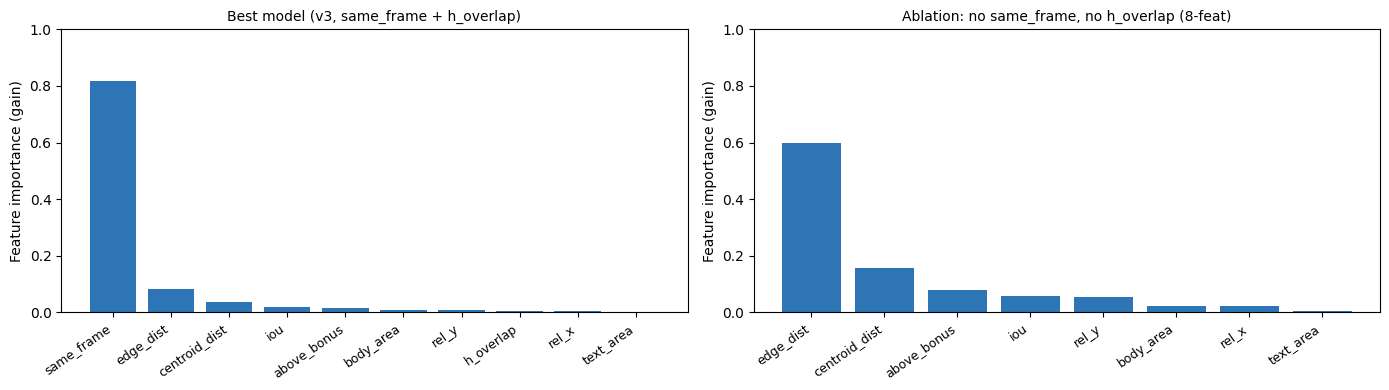

Saved feature_importance_ablation.png


In [ ]:
import matplotlib.pyplot as plt

best = trained_v3_ym["xgb_ym_v3_conf_fixed300"]
nosf = trained_ablation["xgb_ym_nosf_nohov"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (label, d, fnames) in zip(axes, [
    ("Best model (v3, same_frame + h_overlap)",
     best, FEATURE_NAMES_V3),
    ("Ablation: no same_frame, no h_overlap (8-feat)",
     nosf, FEATURE_SETS["v2_nosf_nohov"][1]),
]):
    imp = d["clf"].feature_importances_
    idx = np.argsort(imp)[::-1]
    ax.bar(range(len(imp)), imp[idx], color="#2E75B6")
    ax.set_xticks(range(len(imp)))
    ax.set_xticklabels([fnames[i] for i in idx], rotation=35, ha="right", fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel("Feature importance (gain)")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("/drive/MyDrive/CV-Comic-Project/baselines/feature_importance_ablation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved feature_importance_ablation.png")


### 15.13  Save All Models and Results

In [ ]:
save_dir = "/drive/MyDrive/CV-Comic-Project/baselines/"
os.makedirs(save_dir, exist_ok=True)

# Save learned models
for name, d in all_learned.items():
    safe = name.replace(" ","_").replace("★","star")
    path = os.path.join(save_dir, f"{safe}.pkl")
    with open(path, "wb") as f:
        pickle.dump({
            "clf": d["clf"],
            "scaler": d["scaler"],
            "cols": d["cols"],
        }, f)
    print(f"Saved {safe}.pkl")

# Save all results
all_results_15 = {
    "frame_aware":  result_frame_aware,
    **results_15,
    "xgb_ym_v3_conf_fixed300": result_yolo_conf,  # from §14
}
with open(os.path.join(save_dir, "ablation_results_section15.json"), "w") as f:
    json.dump(all_results_15, f, indent=2)

print("\nAll results saved to ablation_results_section15.json")


Saved xgb_ym_v2_uniform.pkl
Saved xgb_ym_v2_page_diff.pkl
Saved xgb_ym_v2_conf.pkl
Saved xgb_ym_v3_uniform_early.pkl
Saved xgb_ym_v3_uniform_fixed300.pkl
Saved xgb_ym_v3_conf_early.pkl
Saved xgb_ym_v3_conf_fixed300.pkl
Saved xgb_ym_nosf_nohov.pkl
Saved xgb_ym_nosf_hov.pkl
Saved xgb_ym_v3_conf_fixed300_withSPW.pkl

All results saved to ablation_results_section15.json
